# Evaluation

Scores the trained model on the 186 test images it never saw during training,
then breaks that score down to find where the model fails.

*Note:The headline number is not the interesting part. The breakdown is.*

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import torch
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader

from src.dataset import FishDataset
from src.model import build_model
from src.metrics import to_prediction, iou_score

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

SEG = Path("../data/Segmentation")
PLOTS = Path("../plots")
PLOTS.mkdir(exist_ok=True)

## 1. Check the metric on known cases

Three hand-built cases where the answer is known in advance. On real model
output a strange IoU could be either the model or a broken metric, and there
would be no way to tell them apart. Expected results are 1.0, 0.0, and 0.5.

In [2]:
a = torch.zeros(1, 4, 4)
a[0, 1:3, 1:3] = 1  # a 2x2 fish block

b = torch.zeros(1, 4, 4)
b[0, 0, 0] = 1      # nowhere near it

c = torch.zeros(1, 4, 4)
c[0, 1:3, 1:2] = 1  # covers 2 of the 4 fish pixels, nothing extra

print(f"identical:  {iou_score(a, a):.3f}")
print(f"no overlap: {iou_score(a, b):.3f}")
print(f"half:       {iou_score(a, c):.3f}")

identical:  1.000
no overlap: 0.000
half:       0.500


## 2. Load the trained model

`build_model` creates the architecture with a fresh random head. `load_state_dict`
pours the trained weights back in. `map_location` handles the fact that training
ran on a CUDA while this runs on MPS.

In [3]:
model = build_model(num_classes=2)
model.load_state_dict(torch.load("../models/best_model.pth", map_location=device))
model.to(device)
model.eval()

test_ds = FishDataset(SEG / "test.csv", SEG)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

print(f"model loaded, {len(test_ds)} test images")

model loaded, 186 test images


## 3. Score every test image

Scored one image at a time rather than one number per batch.

A single average hides everything useful. A list of 186 individual scores is
what makes the failure analysis below possible.

The same pass also counts false positive pixels on empty images, since IoU
cannot measure those (see section 5).

In [4]:
import numpy as np
from tqdm import tqdm

scores = []                 # IoU for every test image
false_positive_pixels = []  # wrongly-lit pixels on images that contain no fish

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Scoring"):
        images = images.to(device)

        out = model(images)["out"]
        pred = to_prediction(out).cpu()

        for p, m in zip(pred, masks):
            iou = iou_score(p.unsqueeze(0), m.unsqueeze(0))
            scores.append(iou)
            if m.sum() == 0:
                false_positive_pixels.append(int(p.sum()))

scores = np.array(scores)
false_positive_pixels = np.array(false_positive_pixels)

print(f"scored {len(scores)} images, {len(false_positive_pixels)} of them empty")

Scoring: 100%|██████████| 24/24 [00:19<00:00,  1.24it/s]

scored 186 images, 90 of them empty


## 4. The headline number (Score for images with fish)

Two numbers here, and only one of them is honest.

On an empty image with a correct prediction, intersection and union are both
zero, so IoU comes out as 0 even though the model was right. Half the test set
is empty, which drags the overall mean down for entirely the wrong reason.

IoU only means something on images that contain fish, so the fish-only mean is
the number to report.

In [13]:
labels = test_ds.rows["labels"].values
fish_scores = scores[labels == 1]

print(f"mean IoU, all images  : {scores.mean():.3f}     <- misleading")
print(f"median IoU, all images: {np.median(scores):.3f}     <- misleading")
print()
print(f"mean IoU, fish images : {fish_scores.mean():.3f}    <- the real number")
print(f"fish images: {len(fish_scores)} of {len(scores)}")

mean IoU, all images  : 0.406     <- misleading
median IoU, all images: 0.000     <- misleading

mean IoU, fish images : 0.786    <- the real number
fish images: 96 of 186


## 5. False alarms on empty images (Check for empty images)

The right question for an empty frame is not how well the fish was outlined but
whether the model correctly stayed silent. A tank monitor that reports fish in
empty water raises false alarms, which is the production-facing failure mode.

A handful of stray pixels is noise that would be filtered in practice. A blob
covering over 1 percent of the frame is the model genuinely claiming a fish is
there, so the two are counted separately.

In [6]:
total_pixels = 256 * 448

print(f"empty images                     : {len(false_positive_pixels)}")
print(f"perfectly clean (0 false pixels) : {(false_positive_pixels == 0).sum()}")
print(f"under 0.1% of frame              : {(false_positive_pixels < total_pixels * 0.001).sum()}")
print(f"over 1% of frame (real alarm)    : {(false_positive_pixels > total_pixels * 0.01).sum()}")
print(f"worst case                       : {false_positive_pixels.max()} pixels")

empty images                     : 90
perfectly clean (0 false pixels) : 90
under 0.1% of frame              : 90
over 1% of frame (real alarm)    : 0
worst case                       : 0 pixels


**Result.** Zero false positive pixels across all 90 empty images.

Half the training data was empty frames, so the model got substantial practice at
ecognising an empty scene. This is a design choice paying off.

## 6. Distribution, not just the mean

A mean of 0.786 could mean nearly every image scores around 0.78, or it could
mean most score 0.9 and a few score near zero. Those are different models
needing different fixes.

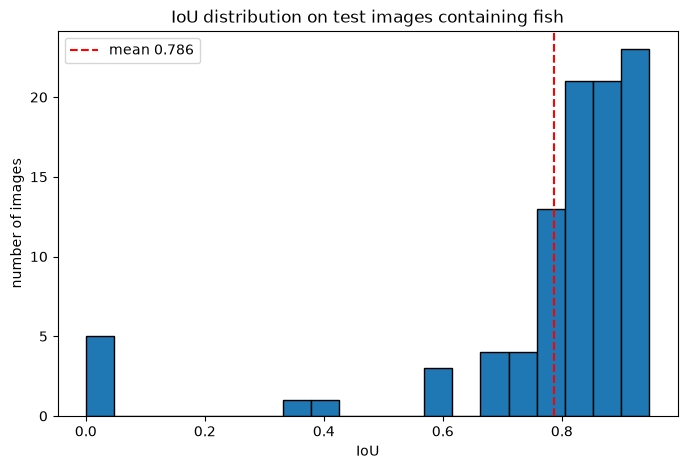

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(fish_scores, bins=20, edgecolor="black")
plt.axvline(
    fish_scores.mean(),
    color="red",
    linestyle="--",
    label=f"mean {fish_scores.mean():.3f}",
)
plt.xlabel("IoU")
plt.ylabel("number of images")
plt.title("IoU distribution on test images containing fish")
plt.legend()
plt.savefig(PLOTS / "iou_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

**Result.** The distribution is bimodal. Most images sit between 0.65 and 0.95,
and 5 images sit at exactly 0.00, with almost nothing in between.

The model does not degrade gracefully. It either finds the fish and outlines it
well, or misses it completely. That matters more than the mean, because a model
that is good 95 percent of the time and blind 5 percent of the time needs a
different fix than one that is mediocre everywhere.

## 7. Look at the failures

In [8]:
order = np.argsort(fish_scores)
fish_rows = test_ds.rows[test_ds.rows["labels"] == 1].reset_index(drop=True)

print("worst 5:")
for i in order[:5]:     # last 5
    print(f"    {fish_rows.iloc[i]['ID']}   IoU {fish_scores[i]:.3f}")

print("\nbest 5:")
for i in order[-5:]:    # first 5
    print(f"    {fish_rows.iloc[i]['ID']}   IoU {fish_scores[i]:.3f}")

worst 5:
    valid/7117_Lutjanus_a_testclip_far_away_short_f000090   IoU 0.000
    valid/9870_Gerres_f000010   IoU 0.000
    valid/9894_gerres_f000030   IoU 0.000
    valid/7117_Lutjanus_argentimaculatus_adult_2_f000030   IoU 0.000
    valid/9870_Gerres_f000110   IoU 0.000

best 5:
    valid/9862_Acanthopagrus_palmaris_f000120   IoU 0.938
    valid/7623_F2_f000410   IoU 0.940
    valid/7623_F2_f000500   IoU 0.940
    valid/7623_F2_f000470   IoU 0.941
    valid/7623_F2_f000480   IoU 0.947


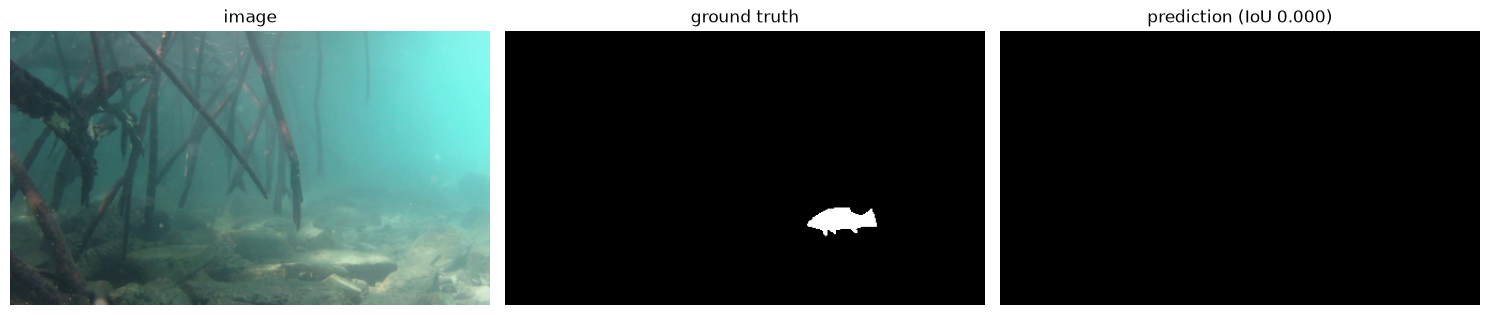

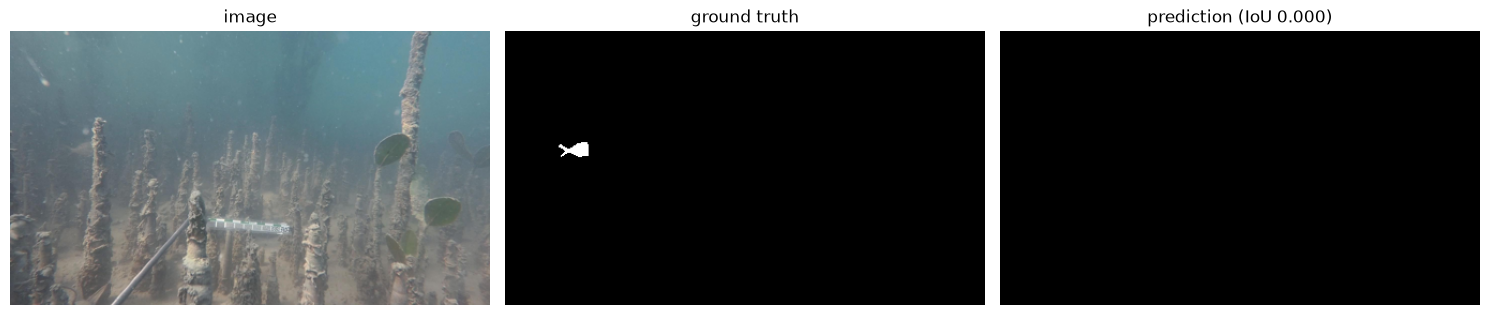

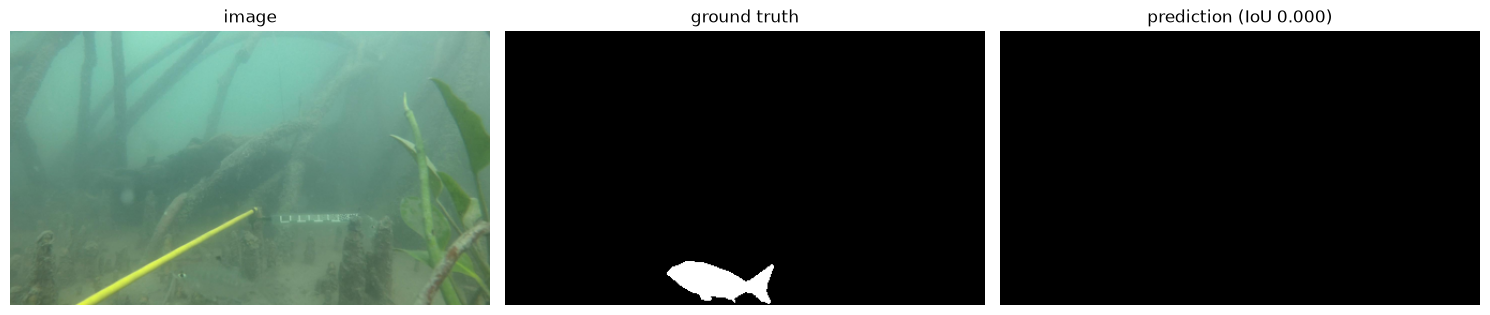

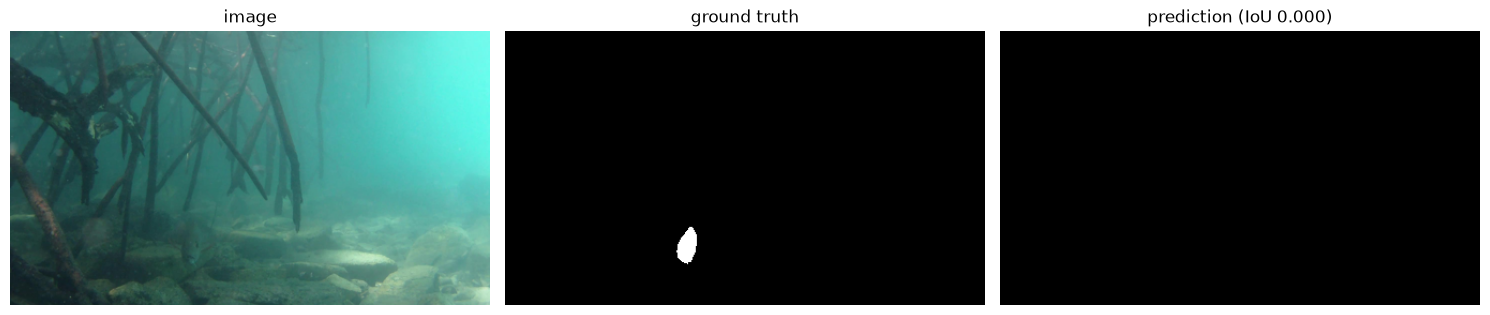

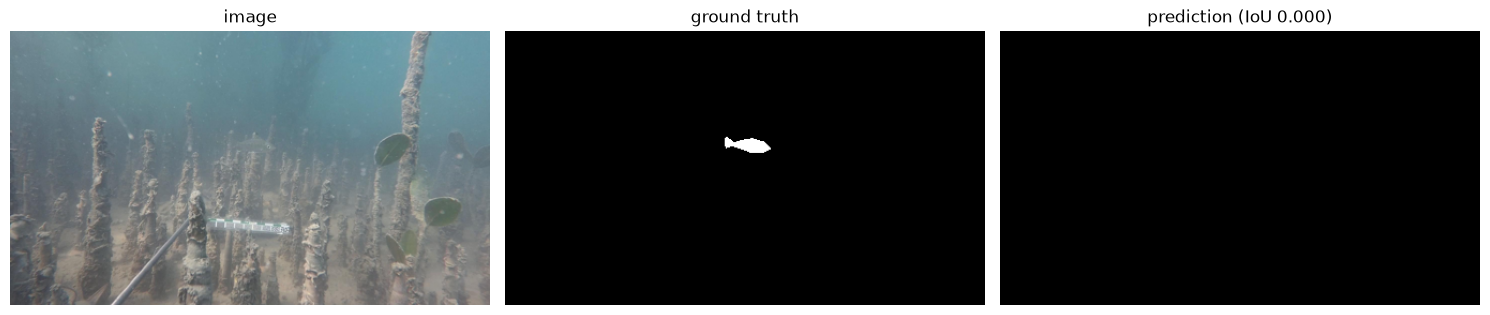

In [9]:
import torchvision.transforms.functional as TF

def show_case(row_id, iou):
    """Image, ground truth, and prediction side by side."""
    image = Image.open(SEG / "images" / f"{row_id}.jpg").resize((448, 256))
    truth = Image.open(SEG / "masks" / f"{row_id}.png").resize((448, 256), Image.NEAREST)

    x = TF.to_tensor(image).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(x)["out"]
        pred = to_prediction(out).cpu()[0]

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].imshow(image)
    ax[0].set_title("image")
    ax[1].imshow(truth, cmap="gray")
    ax[1].set_title("ground truth")
    ax[2].imshow(pred, cmap="gray")
    ax[2].set_title(f"prediction (IoU {iou:.3f})")
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()


for i in order[:5]:
    show_case(fish_rows.iloc[i]["ID"], fish_scores[i])

**Observations**
- In all five failures the fish is genuinely hard to spot by eye.
Camouflage against the substrate, turbid water, distance, and poor image quality.
- Three of the five are *Gerres*, a silvery fish that blends into sandy bottoms,
and one filename is explicitly marked `far_away`.

That is an impression from looking. The next two sections test it.

## 8. Does fish size explain the failures?

Distance means small fish in frame, which is measurable.

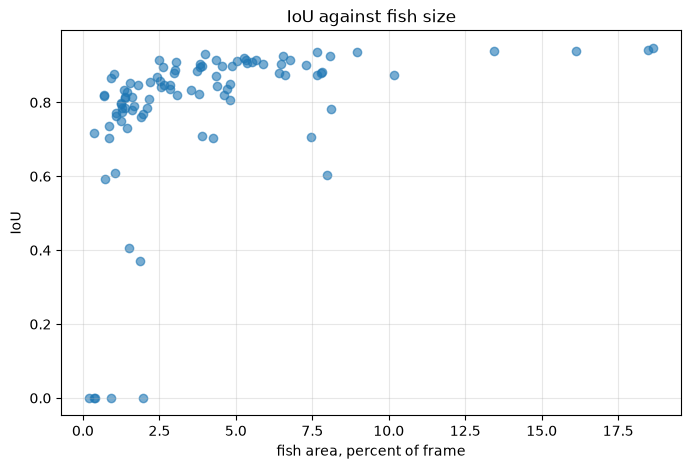

smaller half: mean IoU 0.700
larger half : mean IoU 0.873


In [10]:
fish_sizes = []
for _, row in fish_rows.iterrows():
    m = Image.open(SEG / "masks" / f"{row['ID']}.png").resize((448, 256), Image.NEAREST)
    fish_sizes.append((np.array(m) > 127).sum() / (256 * 448))  # fish pixels / total pixels

fish_sizes = np.array(fish_sizes)

plt.figure(figsize=(8, 5))
plt.scatter(fish_sizes * 100, fish_scores, alpha=0.6)
plt.xlabel("fish area, percent of frame")
plt.ylabel("IoU")
plt.title("IoU against fish size")
plt.grid(alpha=0.3)
plt.savefig(PLOTS / "iou_vs_size.png", dpi=120, bbox_inches="tight")
plt.show()

small = fish_scores[fish_sizes < np.median(fish_sizes)]
large = fish_scores[fish_sizes >= np.median(fish_sizes)]
print(f"smaller half: mean IoU {small.mean():.3f}")
print(f"larger half : mean IoU {large.mean():.3f}")

**Result.** The averages suggest a smooth relationship (0.700 against 0.873) but
the scatter plot shows something sharper.

- Above about 2.5 percent of frame, scores sit between 0.7 and 0.95 with no upward
trend. Size stops mattering once the fish is big enough.
- Below 2.5 percent, some images still score above 0.8 while all five zeros appear.

So small size does not cause failure. It makes failure possible. Below roughly
2 percent of frame the model becomes unreliable rather than uniformly worse.

## 9. Does habitat matter?

Habitats stand in for deployment sites with different water, lighting, and
substrate. Habitats with fewer than 3 test images are excluded, since an average
over one or two images means very little.

In [11]:
fish_rows = fish_rows.copy()
fish_rows["iou"] = fish_scores
fish_rows["area"] = fish_sizes

by_habitat = fish_rows.groupby("habitats")["iou"].agg(["count", "mean"])
by_habitat = by_habitat[by_habitat["count"] >= 3].sort_values("mean")
print(by_habitat.round(3))

          count   mean
habitats              
9870          3  0.239
7117          3  0.272
9894          4  0.638
7585          6  0.676
9866         22  0.794
9908          6  0.820
7398          7  0.827
9892          6  0.828
9852          4  0.846
9862          6  0.852
7623         12  0.883
7482         15  0.906


**Result.** Performance ranges from 0.239 at habitat 9870 to 0.906 at habitat
7482. One model behaving like two, depending on where the footage came from.

The two worst habitats are also where the five zero-score images came from, so
the failures are concentrated by location rather than scattered.

Caveat worth stating: 9870 and 7117 have only 3 test images each, so those are
an indication rather than a firm measurement.

## 10. Is habitat independent of size?

The bad habitats might simply happen to contain small fish, in which case habitat
is just a proxy for size and adds nothing. This holds size roughly constant and
checks whether habitat still separates the scores.

In [ ]:
small_only = fish_rows[fish_rows["area"] < 0.025]

by_hab_small = small_only.groupby("habitats")["iou"].agg(["count", "mean"])
print("small fish only, by habitat:")
print(by_hab_small[by_hab_small["count"] >= 2].sort_values("mean").round(3))

worst = small_only["habitats"].isin([9870, 7117])
print(f"\nsmall fish in worst habitats    : {small_only[worst]['iou'].mean():.3f}")
print(f"small fish elsewhere            : {small_only[~worst]['iou'].mean():.3f}")

small fish only, by habitat:
          count   mean
habitats              
9870          3  0.239
7117          3  0.272
9894          2  0.395
7585          6  0.676
9862          2  0.762
9898          2  0.765
9866         18  0.778
7623          4  0.825

small fish in worst habitats.   : 0.256
small fish elsewhere            : 0.745


**Result.** Holding size roughly constant, small fish in the two worst habitats
score 0.256 against 0.745 elsewhere. Habitat is not a proxy for size. It
separates performance on its own.

Same caveat applies, 9870 and 9894 have 3 and 2 images in this subset.

## Summary

- **0.786 mean IoU** on the 96 test images containing fish.
- **Zero false positives** across all 90 empty images, no stray pixels at all.
- Failures are **bimodal**. The model either segments the fish well or misses it
  entirely, with little in between.
- Small fish (**under about 2 percent of frame**) are where failure becomes
  possible, though many small fish are still segmented well.
- Performance **varies widely by habitat**, from 0.24 to 0.91, and the failures
  cluster in two specific locations rather than spreading evenly.
- **Habitat matters independently of size.** Among small fish only, the two worst
  habitats score 0.256 against 0.745 elsewhere.